# Term Deposit Marketing — Model Selection & Tuning

Trains and compares classifiers for predicting term deposit subscription (`y`) across multiple feature representations and resampling strategies.

**Contents**
1. Imports & data loading
2. Train/test split, scaling, and resampling (SMOTE / random undersampling)
3. Stage 1 — cheap comparison of six classifiers across six datasets
4. Stage 2 — feature selection via ANOVA F-test
5. Stage 3 — hyperparameter tuning (XGBoost) and threshold optimization
6. Save/reload the final model

# Imports

In [ ]:
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm, neighbors
from sklearn.metrics import f1_score
from xgboost import XGBClassifier, plot_importance

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

In [7]:
# Load processed datasets
# df with dummy categorical variables, no missing data
dummy_df = pd.read_csv("../data/processed/dummy_df_no_missing.csv")
# df with dummy categorical variables, missing data in contact column
dummy_full_contact_df = pd.read_csv("../data/processed/dummy_df_with_contact.csv")
# df with encoded categorical variables, no missing data
encoded_df = pd.read_csv("../data/processed/encoded_df_no_missing.csv")
# df with encoded categorical variables, missing data in contact column
encoded_full_contact_df = pd.read_csv("../data/processed/encoded_df_with_contact.csv")

# df with engineered features
engineered_df = pd.read_csv("../data/processed/engineered_df.csv")
engineered_full_contact_df = pd.read_csv("../data/processed/engineered_df_with_contact.csv")

In [8]:
datasets = {
    "encoded_with_contact": encoded_full_contact_df,
    "encoded": encoded_df,
    "dummy_with_contact": dummy_full_contact_df,
    "dummy": dummy_df,
    "engineered": engineered_df,
    "engineered_with_contact": engineered_full_contact_df
}

In [9]:
engineered_df.describe()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y,quarter,season,campaign_squared,duration_log
count,26295.000000,26295.000000,26295.000000,26295.000000,26295.000000,26295.000000,26295.000000,26295.000000,26295.000000,26295.000000,26295.000000,26295.000000,26295.000000,26295.000000,26295.000000,26295.000000,26295.000000,26295.000000
mean,40.356570,4.410420,1.164556,1.186461,0.019281,1304.010801,0.545579,0.184218,0.083172,16.293364,4.699258,254.581631,2.901921,0.088040,2.548469,2.565735,18.207036,5.142245
std,9.688926,3.242563,0.608595,0.659110,0.137514,3000.093812,0.497928,0.387669,0.276147,8.146041,3.147134,261.030167,3.128301,0.283358,0.886114,0.874495,69.110827,0.932582
min,19.000000,0.000000,0.000000,0.000000,0.000000,-8019.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,33.000000,1.000000,1.000000,1.000000,0.000000,56.000000,0.000000,0.000000,0.000000,9.000000,1.000000,98.000000,1.000000,0.000000,2.000000,2.000000,1.000000,4.595120
50%,38.000000,4.000000,1.000000,1.000000,0.000000,411.000000,1.000000,0.000000,0.000000,17.000000,5.000000,172.000000,2.000000,0.000000,3.000000,3.000000,4.000000,5.153292
75%,48.000000,7.000000,2.000000,2.000000,0.000000,1335.000000,1.000000,0.000000,0.000000,21.000000,8.000000,313.000000,3.000000,0.000000,3.000000,3.000000,9.000000,5.749393
max,95.000000,10.000000,2.000000,2.000000,1.000000,102127.000000,1.000000,1.000000,1.000000,31.000000,10.000000,4918.000000,50.000000,1.000000,4.000000,4.000000,2500.000000,8.500861


# Train/Test Split

In [10]:
def prepare_data(df):
    # Separate features and target
    X = df.drop(columns='y')
    y = df["y"]

    # Create training and testing datasets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    scaler = StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

    # Synthetic Minority Over-sampling Technique (SMOTE)
    sm = SMOTE(random_state=42)
    X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

    # Random undersampler
    rus = RandomUnderSampler(random_state=42)
    X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

    return {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "X_train_sm": X_train_sm,
        "y_train_sm": y_train_sm,
        "X_train_rus": X_train_rus,
        "y_train_rus": y_train_rus,
    }

In [11]:
results = {}
for name, df in datasets.items():
    results[name] = prepare_data(df)

# Stage 1: Cheap Model Comparison

## Logistic Regression

In [12]:
comparison = []
for name, data in results.items():

    # SMOTE model
    model_sm = LogisticRegression(random_state=42, max_iter=2000)
    model_sm.fit(data["X_train_sm"], data["y_train_sm"])
    y_pred_sm = model_sm.predict(data["X_test"])
    f1_sm = f1_score(data["y_test"], y_pred_sm)

    # Random undersampling model
    model_rus = LogisticRegression(random_state=42, max_iter=2000)
    model_rus.fit(data["X_train_rus"], data["y_train_rus"])
    y_pred_rus = model_rus.predict(data["X_test"])
    f1_rus = f1_score(data["y_test"], y_pred_rus)

    comparison.append({
        "Dataset": name,
        "SMOTE F1": f1_sm,
        "RUS F1": f1_rus
    })

print(pd.DataFrame(comparison))

                   Dataset  SMOTE F1    RUS F1
0     encoded_with_contact  0.450745  0.453461
1                  encoded  0.472750  0.465704
2       dummy_with_contact  0.485801  0.480712
3                    dummy  0.519695  0.506550
4               engineered  0.461538  0.462359
5  engineered_with_contact  0.436245  0.427335


## Random Forest

In [13]:
comparison = []
for name, data in results.items():

    # SMOTE model
    model_sm = RandomForestClassifier(n_estimators=100,random_state=42)
    model_sm.fit(data["X_train_sm"], data["y_train_sm"])
    y_pred_sm = model_sm.predict(data["X_test"])
    f1_sm = f1_score(data["y_test"], y_pred_sm)

    # Random undersampling model
    model_rus = RandomForestClassifier(n_estimators=100,random_state=42)
    model_rus.fit(data["X_train_rus"], data["y_train_rus"])
    y_pred_rus = model_rus.predict(data["X_test"])
    f1_rus = f1_score(data["y_test"], y_pred_rus)

    comparison.append({
        "Dataset": name,
        "SMOTE F1": f1_sm,
        "RUS F1": f1_rus
    })

print(pd.DataFrame(comparison))

                   Dataset  SMOTE F1    RUS F1
0     encoded_with_contact  0.548256  0.490839
1                  encoded  0.566990  0.513881
2       dummy_with_contact  0.526141  0.483886
3                    dummy  0.534113  0.505855
4               engineered  0.577693  0.528020
5  engineered_with_contact  0.541700  0.488061


## Decision Tree

In [14]:
comparison = []
for name, data in results.items():

    # SMOTE model
    model_sm = DecisionTreeClassifier(random_state=42)
    model_sm.fit(data["X_train_sm"], data["y_train_sm"])
    y_pred_sm = model_sm.predict(data["X_test"])
    f1_sm = f1_score(data["y_test"], y_pred_sm)

    # Random undersampling model
    model_rus = DecisionTreeClassifier(random_state=42)
    model_rus.fit(data["X_train_rus"], data["y_train_rus"])
    y_pred_rus = model_rus.predict(data["X_test"])
    f1_rus = f1_score(data["y_test"], y_pred_rus)

    comparison.append({
        "Dataset": name,
        "SMOTE F1": f1_sm,
        "RUS F1": f1_rus
    })

print(pd.DataFrame(comparison))

                   Dataset  SMOTE F1    RUS F1
0     encoded_with_contact  0.445840  0.392174
1                  encoded  0.451967  0.423973
2       dummy_with_contact  0.441518  0.395073
3                    dummy  0.440400  0.420940
4               engineered  0.467253  0.438627
5  engineered_with_contact  0.418251  0.404762


## XGBoost

In [15]:
comparison = []
for name, data in results.items():

    # SMOTE model
    model_sm = XGBClassifier(random_state=42)
    model_sm.fit(data["X_train_sm"], data["y_train_sm"])
    y_pred_sm = model_sm.predict(data["X_test"])
    f1_sm = f1_score(data["y_test"], y_pred_sm)

    # Random undersampling model
    model_rus = XGBClassifier(random_state=42)
    model_rus.fit(data["X_train_rus"], data["y_train_rus"])
    y_pred_rus = model_rus.predict(data["X_test"])
    f1_rus = f1_score(data["y_test"], y_pred_rus)

    comparison.append({
        "Dataset": name,
        "SMOTE F1": f1_sm,
        "RUS F1": f1_rus
    })

print(pd.DataFrame(comparison))

                   Dataset  SMOTE F1    RUS F1
0     encoded_with_contact  0.541555  0.488235
1                  encoded  0.557068  0.518430
2       dummy_with_contact  0.549822  0.487591
3                    dummy  0.539683  0.522370
4               engineered  0.571739  0.527778
5  engineered_with_contact  0.520623  0.493888


## SVM

In [16]:
comparison = []
for name, data in results.items():

    # SMOTE model
    model_sm = svm.SVC(random_state=42)
    model_sm.fit(data["X_train_sm"], data["y_train_sm"])
    y_pred_sm = model_sm.predict(data["X_test"])
    f1_sm = f1_score(data["y_test"], y_pred_sm)

    # Random undersampling model
    model_rus = svm.SVC(random_state=42)
    model_rus.fit(data["X_train_rus"], data["y_train_rus"])
    y_pred_rus = model_rus.predict(data["X_test"])
    f1_rus = f1_score(data["y_test"], y_pred_rus)

    comparison.append({
        "Dataset": name,
        "SMOTE F1": f1_sm,
        "RUS F1": f1_rus
    })

print(pd.DataFrame(comparison))

KeyboardInterrupt: 

## KNN

In [ ]:
comparison = []
for name, data in results.items():

    # SMOTE model
    model_sm = neighbors.KNeighborsClassifier()
    model_sm.fit(data["X_train_sm"], data["y_train_sm"])
    y_pred_sm = model_sm.predict(data["X_test"])
    f1_sm = f1_score(data["y_test"], y_pred_sm)

    # Random undersampling model
    model_rus = neighbors.KNeighborsClassifier()
    model_rus.fit(data["X_train_rus"], data["y_train_rus"])
    y_pred_rus = model_rus.predict(data["X_test"])
    f1_rus = f1_score(data["y_test"], y_pred_rus)

    comparison.append({
        "Dataset": name,
        "SMOTE F1": f1_sm,
        "RUS F1": f1_rus
    })

print(pd.DataFrame(comparison))

                   Dataset  SMOTE F1    RUS F1
0     encoded_with_contact  0.472663  0.446471
1                  encoded  0.480392  0.447536
2       dummy_with_contact  0.454047  0.400546
3                    dummy  0.447848  0.411662
4               engineered  0.503341  0.465145
5  engineered_with_contact  0.477919  0.446620


After the preliminary tests, on all four datasets and two sampling models:
* Removing the missing data from the contact column (although it is a larger portion, seems to give more accurate results)
* Using the under sampling method tends to be better than using the oversampling method
* Our top performing models are XGBoost and Random Forest Classifier

# Stage 2: Feature Selection (ANOVA F-test)

In [17]:
# Using the engineered dataset for feature selection
data = results['engineered']

print(data['X_test'].shape)
print(data['X_train_sm'].shape)

(5259, 20)
(38368, 20)


In [18]:
from sklearn.feature_selection import SelectKBest, f_classif

def select_features(X, y, k=10):
    selector = SelectKBest(f_classif, k=k)
    selector.fit(X, y)

    f_scores = pd.DataFrame({
        'feature': X.columns,
        'f_score': selector.scores_,
        'p_value': selector.pvalues_
    }).sort_values('f_score', ascending=False).reset_index(drop=True)

    selected_features = list(X.columns[selector.get_support()])
    return f_scores, selected_features


f_scores, selected_features = select_features(data['X_train'], data['y_train'], k='all')
print(f_scores)
print(selected_features)

             feature      f_score       p_value
0           duration  5648.905272  0.000000e+00
1       duration_log  3204.157359  0.000000e+00
2          long_call  2033.816814  0.000000e+00
3              march   445.217776  8.172820e-98
4            quarter   158.023735  4.124121e-36
5             season    76.785636  2.047272e-18
6           campaign    55.160459  1.153141e-13
7            housing    52.234414  5.093868e-13
8               loan    39.715078  2.996814e-10
9          education    39.705002  3.012285e-10
10           marital    33.199905  8.431562e-09
11           balance    29.546404  5.520094e-08
12  campaign_squared    24.108977  9.171723e-07
13     many_contacts    19.493919  1.014231e-05
14               day     9.180202  2.449441e-03
15           contact     6.330265  1.187684e-02
16               age     4.947460  2.613960e-02
17           default     3.835582  5.018876e-02
18               job     2.757597  9.680843e-02
19             month     1.759825  1.846

In [25]:
x_data = data['X_train'][selected_features]


# Stage 3: Hyperparameter Tuning

## XGBoost

In [21]:
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(
        objective='binary:logistic',
        random_state=42,
    ))
])

In [ ]:
param_grid = {
    'classifier__max_depth': [3, 5, 7],
    'classifier__min_child_weight': [1, 3, 5],
    'classifier__subsample': [0.6, 0.8, 1.0],
    'classifier__colsample_bytree': [0.6, 0.8, 1.0],
    'classifier__learning_rate': [0.01, 0.1, 0.3],
    'classifier__n_estimators': [50, 100, 200]
}

xgb_grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='f1')
xgb_grid_search.fit(x_data, data['y_train'])

print(f"Best parameters: {xgb_grid_search.best_params_}")
print(f"Best CV average precision: {xgb_grid_search.best_score_}")

Best parameters: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 7, 'classifier__min_child_weight': 5, 'classifier__n_estimators': 50, 'classifier__subsample': 1.0}
Best CV average precision: 0.5844496934780222


In [23]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve

model = xgb_grid_search.best_estimator_

oof_probs = cross_val_predict(
    model, data['X_train'], data['y_train'],
    cv=5, method='predict_proba', n_jobs=-1
)[:, 1]

prec, rec, thresholds = precision_recall_curve(data['y_train'], oof_probs)
f1_scores = 2 * prec * rec / (prec + rec + 1e-9)
best_threshold = thresholds[np.argmax(f1_scores[:-1])]

print(f"Best threshold (out-of-fold): {best_threshold:.4f}")
print(f"Out-of-fold F1 at this threshold: {f1_scores[:-1].max():.4f}")

Best threshold (out-of-fold): 0.5275
Out-of-fold F1 at this threshold: 0.5887


In [24]:
with open('../models/xgb_model.pkl', 'wb') as file:
    pickle.dump({'model': xgb_grid_search.best_estimator_, 'threshold': best_threshold}, file).best_estimator_, 'threshold': best_threshold}, file)

SyntaxError: unmatched '}' (1618200994.py, line 2)

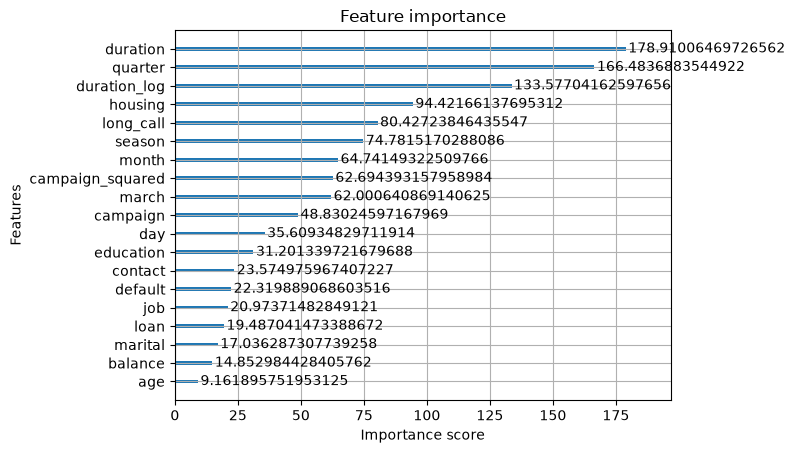

In [ ]:
plot_importance(model.named_steps['classifier'], importance_type="gain")
plt.show()

## Logistic Regression

In [ ]:
lr_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(random_state=42, max_iter=2000))
])

In [ ]:
lr_param_grid = [
    {
        'classifier__penalty': ['l1', 'l2'],
        'classifier__C': [0.01, 0.1, 1, 10, 100],
        'classifier__solver': ['liblinear, lbfgs']
    }
]

lr_grid_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    cv=5,
    n_jobs=-1,
    scoring='f1')
lr_grid_search.fit(x_data, data['y_train'])

print(f"Best parameters: {lr_grid_search.best_params_}")
print(f"Best CV F1 score: {lr_grid_search.best_score_}")

/Users/megmkr/Documents/Documents - Megan’s MacBook Air/Apziva/TermDepositMarketing/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/megmkr/Documents/Documents - Megan’s MacBook Air/Apziva/TermDepositMarketing/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/megmkr/Documents/Documents - Megan’s MacBook Air/Apziva/TermDepositMarketing/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: Future

Best parameters: {'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Best CV F1 score: 0.4533761842332698


/Users/megmkr/Documents/Documents - Megan’s MacBook Air/Apziva/TermDepositMarketing/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [ ]:
with open('../models/lr_model.pkl', 'wb') as file:
    pickle.dump({'model': lr_grid_search.best_estimator_}, file)

## Random Forest

In [ ]:
rf_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [26]:
rf_param_grid = {
    'classifier__n_estimators': [100, 200, 400],
    'classifier__max_depth': [None, 5, 10, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2']
}

rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    n_jobs=-1,
    scoring='f1')
rf_grid_search.fit(x_data, data['y_train'])

print(f"Best parameters: {rf_grid_search.best_params_}")
print(f"Best CV F1 score: {rf_grid_search.best_score_}")

Best parameters: {'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 400}
Best CV F1 score: 0.5726384003258761


In [27]:
with open('../models/rf_model.pkl', 'wb') as file:
    pickle.dump({'model': rf_grid_search.best_estimator_}, file)

## Decision Tree

In [28]:
dt_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

In [29]:
dt_param_grid = {
    'classifier__max_depth': [3, 5, 10, 20, None],
    'classifier__min_samples_split': [2, 5, 10, 20],
    'classifier__min_samples_leaf': [1, 2, 4, 8],
    'classifier__criterion': ['gini', 'entropy']
}

dt_grid_search = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_param_grid,
    cv=5,
    n_jobs=-1,
    scoring='f1')
dt_grid_search.fit(x_data, data['y_train'])

print(f"Best parameters: {dt_grid_search.best_params_}")
print(f"Best CV F1 score: {dt_grid_search.best_score_}")

Best parameters: {'classifier__criterion': 'gini', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
Best CV F1 score: 0.5220171080042713


In [30]:
with open('../models/dt_model.pkl', 'wb') as file:
    pickle.dump({'model': dt_grid_search.best_estimator_}, file)

## SVM

In [36]:
svm_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', svm.SVC(random_state=42, max_iter=5000))
])

In [37]:
svm_param_grid = [
    {'classifier__C': [0.1, 1], 'classifier__kernel': ['rbf'], 'classifier__gamma': ['scale', 'auto']},
    {'classifier__C': [0.1, 1], 'classifier__kernel': ['linear']},
]

svm_grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    cv=3,
    n_jobs=-1,
    scoring='f1')
svm_grid_search.fit(x_data, data['y_train'])

print(f"Best parameters: {svm_grid_search.best_params_}")
print(f"Best CV F1 score: {svm_grid_search.best_score_}")

/Users/megmkr/Documents/Documents - Megan’s MacBook Air/Apziva/TermDepositMarketing/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/megmkr/Documents/Documents - Megan’s MacBook Air/Apziva/TermDepositMarketing/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/megmkr/Documents/Documents - Megan’s MacBook Air/Apziva/TermDepositMarketing/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/megmkr/Documents/Documents - Megan’s MacBook Air/Apziva/TermDepositMarketing/.venv/lib/python3.11/site-packa

Best parameters: {'classifier__C': 1, 'classifier__gamma': 'auto', 'classifier__kernel': 'rbf'}
Best CV F1 score: 0.513828698256274


/Users/megmkr/Documents/Documents - Megan’s MacBook Air/Apziva/TermDepositMarketing/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


In [38]:
with open('../models/svm_model.pkl', 'wb') as file:
    pickle.dump({'model': svm_grid_search.best_estimator_}, file)

## KNN

In [33]:
knn_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', neighbors.KNeighborsClassifier())
])

In [34]:
knn_param_grid = {
    'classifier__n_neighbors': [3, 9, 15],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__p': [1, 2]
}

knn_grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    cv=3,
    n_jobs=-1,
    scoring='f1')
knn_grid_search.fit(x_data, data['y_train'])

print(f"Best parameters: {knn_grid_search.best_params_}")
print(f"Best CV F1 score: {knn_grid_search.best_score_}")

Best parameters: {'classifier__n_neighbors': 15, 'classifier__p': 1, 'classifier__weights': 'uniform'}
Best CV F1 score: 0.5036865522373195


In [35]:
with open('../models/knn_model.pkl', 'wb') as file:
    pickle.dump({'model': knn_grid_search.best_estimator_}, file)

# Open Model 

In [ ]:
with open('../models/xgb_model.pkl', 'rb') as file:
    saved = pickle.load(file)

model = saved['model']
threshold = saved['threshold']

x_test = data['X_test'][selected_features]

probs_test = model.predict_proba(x_test)[:, 1]
y_pred = (probs_test >= threshold).astype(int)
score = f1_score(data["y_test"], y_pred)
print(f"Test F1 (tuned threshold={threshold:.4f}): {score:.4f}")

Test F1 (tuned threshold=0.5129): 0.5159
